Các thư viện bổ sung sau đây là cần thiết để chạy notebook này. Lưu ý rằng việc chạy trên Colab vẫn đang trong quá trình thử nghiệm, vui lòng báo cáo sự cố trên Github nếu bạn gặp bất kỳ vấn đề nào.

In [ ]:
# Cài đặt thư viện d2l phiên bản 1.0.3
!pip install d2l==1.0.3 --no-deps

# Triển khai súc tích mô hình Softmax Regression
:label:`sec_softmax_concise`

Tương tự như cách các framework học sâu bậc cao giúp việc triển khai hồi quy tuyến tính trở nên dễ dàng hơn (xem :numref:`sec_linear_concise`), chúng cũng mang lại sự tiện lợi tương tự ở đây.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

## Định nghĩa Mô hình

Giống như trong :numref:`sec_linear_concise`, chúng ta xây dựng lớp liên kết đầy đủ (fully connected layer) bằng cách sử dụng lớp dựng sẵn của framework. Phương thức `__call__` dựng sẵn sau đó sẽ tự động gọi hàm `forward` bất khi nào chúng ta cần áp dụng mạng vào một đầu vào nào đó.

Chúng ta sử dụng một lớp `Flatten` để chuyển đổi tensor bậc bốn `X` thành tensor bậc hai bằng cách giữ nguyên kích thước dọc theo trục đầu tiên (batch size).

In [ ]:
class SoftmaxRegression(d2l.Classifier):  #@save
    """Mô hình hồi quy Softmax."""
    def __init__(self, num_outputs, lr):
        super().__init__()
        # Lưu các siêu tham số đầu vào (số lượng đầu ra, tốc độ học lr)
        self.save_hyperparameters()
        # Định nghĩa mạng nơ-ron: Phẳng hóa đầu vào sau đó đi qua lớp Tuyến tính (Linear)
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.LazyLinear(num_outputs))

    def forward(self, X):
        # Lan truyền xuôi qua mạng nơ-ron
        return self.net(X)

## Xem xét lại hàm Softmax
:label:`subsec_softmax-implementation-revisited`

Trong phần :numref:`sec_softmax_scratch`, chúng ta đã tính toán đầu ra của mô hình và áp dụng hàm mất mát cross-entropy trực tiếp. Mặc dù điều này hoàn toàn hợp lý về mặt toán học, nhưng nó lại tiềm ẩn rủi ro về mặt tính toán trên máy tính do hiện tượng tràn số dưới (underflow) và tràn số trên (overflow) khi thực hiện phép tính lũy thừa.

Hãy nhớ lại rằng hàm softmax tính toán xác suất thông qua công thức:
$\hat y_j = rac{\exp(o_j)}{\sum_k \exp(o_k)}$.
Nếu một số giá trị $o_k$ rất lớn (số dương lớn), thì $\exp(o_k)$ có thể vượt quá số lớn nhất mà kiểu dữ liệu máy tính có thể biểu diễn. Đây gọi là hiện tượng *tràn số trên* (overflow). Tương tự, nếu tất cả các đối số là số âm rất lớn, chúng ta sẽ gặp hiện tượng *tràn số dưới* (underflow).
Ví dụ, số thực dấu phẩy động độ chính xác đơn (single precision floating point - float32) xấp xỉ bao phủ phạm vi từ $10^{-38}$ đến $10^{38}$. Do đó, nếu số lớn nhất trong $\mathbf{o}$ nằm ngoài khoảng $[-90, 90]$, kết quả sẽ không ổn định.
Một cách để giải quyết vấn đề này là trừ đi giá trị lớn nhất $\bar{o} \stackrel{\textrm{def}}{=} \max_k o_k$ từ tất cả các phần tử:

$$
\hat y_j = \frac{\exp o_j}{\sum_k \exp o_k} =
\frac{\exp(o_j - \bar{o}) \exp \bar{o}}{\sum_k \exp (o_k - \bar{o}) \exp \bar{o}} =
\frac{\exp(o_j - \bar{o})}{\sum_k \exp (o_k - \bar{o})}.
$$

Theo cách xây dựng này, ta biết chắc chắn rằng $o_j - \bar{o} \leq 0$ với mọi $j$. Do đó, đối với bài toán phân loại $q$ lớp, mẫu số sẽ nằm trong khoảng $[1, q]$. Hơn nữa, tử số không bao giờ vượt quá $1$, giúp ngăn ngừa hiện tượng tràn số trên. Hiện tượng tràn số dưới chỉ xảy ra khi $\exp(o_j - \bar{o})$ được tính toán trên máy tính bằng $0$. Tuy nhiên, chúng ta có thể gặp rắc rối ở các bước tiếp theo khi muốn tính $\log \hat{y}_j$ dưới dạng $\log 0$. Đặc biệt, trong quá trình lan truyền ngược (backpropagation), chúng ta có thể phải đối mặt với một màn hình đầy kết quả lỗi `NaN` (Not a Number).

May mắn thay, chúng ta được cứu bởi thực tế là mặc dù chúng ta đang tính các hàm mũ, nhưng mục tiêu cuối cùng là lấy log của chúng (khi tính toán hàm mất mát cross-entropy). Bằng cách kết hợp softmax và cross-entropy, chúng ta có thể tránh hoàn toàn các vấn đề về độ ổn định số học này. Ta có:

$$
\log \hat{y}_j =
\log \frac{\exp(o_j - \bar{o})}{\sum_k \exp (o_k - \bar{o})} =
o_j - \bar{o} - \log \sum_k \exp (o_k - \bar{o}).
$$

Công thức này giúp tránh cả tràn số trên và tràn số dưới.
Chúng ta vẫn muốn giữ lại hàm softmax thông thường để sử dụng khi cần đánh giá xác suất đầu ra của mô hình. Nhưng thay vì truyền trực tiếp xác suất softmax vào hàm mất mát mới, chúng ta chỉ cần **truyền trực tiếp các logits (đầu ra chưa chuẩn hóa) và tính toán đồng thời cả softmax lẫn log của nó bên trong hàm mất mát cross-entropy**, nơi áp dụng các kỹ thuật thông minh như ["LogSumExp trick"](https://en.wikipedia.org/wiki/LogSumExp).

In [ ]:
@d2l.add_to_class(d2l.Classifier)  #@save
def loss(self, Y_hat, Y, averaged=True):
    # Định hình lại đầu ra dự đoán Y_hat thành tensor 2 chiều
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
    # Định hình lại nhãn thực tế Y thành tensor 1 chiều
    Y = Y.reshape((-1,))
    # Sử dụng F.cross_entropy tích hợp sẵn để tính toán ổn định về mặt số học
    return F.cross_entropy(
        Y_hat, Y, reduction='mean' if averaged else 'none')

## Huấn luyện

Tiếp theo, chúng ta tiến hành huấn luyện mô hình. Chúng ta sử dụng tập dữ liệu ảnh Fashion-MNIST, được làm phẳng thành các vectơ đặc trưng 784 chiều.

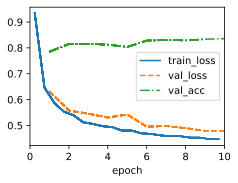

In [ ]:
# Tải dữ liệu FashionMNIST với kích thước batch là 256
data = d2l.FashionMNIST(batch_size=256)
# Khởi tạo mô hình Softmax Regression với 10 lớp đầu ra và tốc độ học lr = 0.1
model = SoftmaxRegression(num_outputs=10, lr=0.1)
# Khởi tạo bộ huấn luyện (Trainer) chạy tối đa 10 epochs
trainer = d2l.Trainer(max_epochs=10)
# Tiến hành khớp và huấn luyện mô hình với dữ liệu đã tải
trainer.fit(model, data)

Giống như trước, thuật toán này hội tụ đến một kết quả có độ chính xác khá tốt, tuy nhiên lần này chúng ta viết ít dòng code hơn rất nhiều.


## Tóm tắt

Các API bậc cao rất tiện lợi trong việc che giấu đi những khía cạnh có khả năng nguy hiểm đối với người dùng, chẳng hạn như tính ổn định số học. Hơn nữa, chúng cho phép người dùng thiết kế mô hình một cách cô đọng chỉ với rất ít dòng code. Đây vừa là một điểm lợi vừa là một điểm hại. Lợi ích rõ ràng là nó giúp cho học sâu trở nên dễ tiếp cận hơn, ngay cả với những kỹ sư chưa từng học qua một lớp thống kê nào. Nhưng việc che giấu các góc cạnh sắc nhọn cũng đi kèm với một cái giá: nó làm giảm động lực tự xây dựng các thành phần mới và khác biệt, vì người dùng không có nhiều cơ hội rèn luyện tư duy thực hành tự tay làm. Hơn nữa, nó khiến việc *sửa lỗi* trở nên khó khăn hơn bất cứ khi nào lớp đệm bảo vệ của một framework không bao quát hết được tất cả các trường hợp đặc biệt.

Do đó, chúng tôi thực sự khuyên bạn nên xem xét *cả hai* phiên bản: phiên bản tự triển khai chi tiết từ đầu (bare bones) và phiên bản sử dụng thư viện tinh gọn. Mặc dù chúng tôi nhấn mạnh tính dễ hiểu, nhưng các triển khai trong sách thông thường vẫn đạt hiệu năng rất cao (trừ phép toán tích chập convolution). Ý định của chúng tôi là giúp bạn có đủ nền tảng để tự xây dựng dựa trên những thứ này khi bạn muốn sáng tạo ra một thứ gì đó hoàn toàn mới mà không một framework nào cung cấp sẵn.


## Bài tập

1. Học sâu sử dụng nhiều định dạng số khác nhau, bao gồm FP64 độ chính xác kép (cực kỳ hiếm khi dùng), FP32 độ chính xác đơn, BFLOAT16 (tốt cho biểu diễn nén), FP16 (rất không ổn định), TF32 (một định dạng mới từ NVIDIA) và INT8. Hãy tính toán đối số nhỏ nhất và lớn nhất của hàm mũ để kết quả không dẫn đến tràn số dưới hoặc tràn số trên.
2. INT8 là một định dạng rất hạn chế bao gồm các số khác không từ $1$ đến $255$. Làm thế nào bạn có thể mở rộng phạm vi động của nó mà không cần sử dụng thêm bit? Các phép toán nhân và cộng thông thường có còn hoạt động không?
3. Tăng số lượng epoch khi huấn luyện. Tại sao độ chính xác trên tập kiểm định (validation accuracy) lại có thể giảm sau một khoảng thời gian? Làm thế nào để khắc phục điều này?
4. Điều gì xảy ra khi bạn tăng tốc độ học (learning rate)? Hãy so sánh các đường cong biểu diễn hàm mất mát cho một vài tốc độ học khác nhau. Cái nào hoạt động tốt hơn? Khi nào?

[Thảo luận](https://discuss.d2l.ai/t/53)